In [1]:
%load_ext autoreload
%autoreload 2

In [130]:
from typing import Callable, Tuple, Protocol
from abc import ABC, abstractmethod

from pymc_marketing.mmm.transformers import batched_convolution
import pymc_marketing as pm_mrk
from pymc_marketing.mmm import HSGP, WeeklyFourier, HSGPPeriodic, YearlyFourier
from pymc_marketing.prior import Prior, handle_dims
import pymc as pm
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

import pytensor.tensor as pt
import dowhy

from search_click_prediction.data_generation import generate_data_search_data
from search_click_prediction.model_wrapper import (
    PriorWrapper, HSGPWrapper, 
    FourierWrapper, DataWrapper
)
from search_click_prediction.transforms import (
    hill
)

In [131]:
causal_graph = """digraph {
geo -> search_volume;
time -> search_volume;
time -> budget;
time -> observed_clicks;
geo -> budget;
budget -> impressions;
search_volume -> impressions;
impressions -> observed_clicks;
}"""

In [132]:
data = generate_data_search_data()

In [133]:
data.to_dataframe().reset_index().to_csv("search_click_data.csv", index=False)

## Search Click Prediction

/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/dowhy/causal_model.py:583: UserWarning: 1 variables are assumed unobserved because they are not in the dataset. Configure the logging level to `logging.WARNING` or higher for additional details.
  warnings.warn(


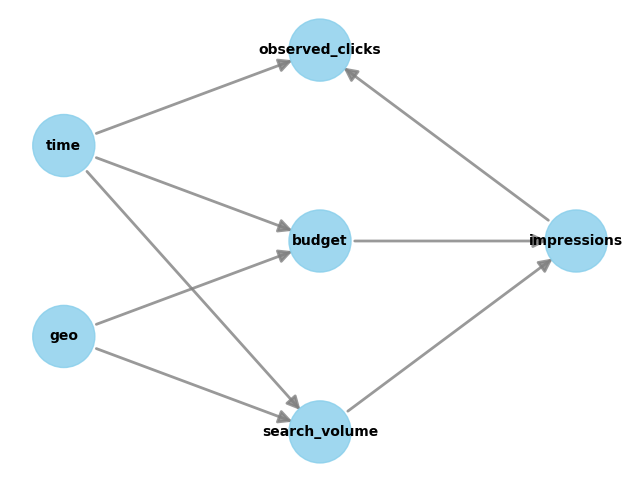

In [134]:
model = dowhy.CausalModel(
    data=data.to_dataframe(),
    graph=causal_graph.replace("\n", " "),
    treatment="budget",
    outcome="observed_clicks",
)
model.view_model()

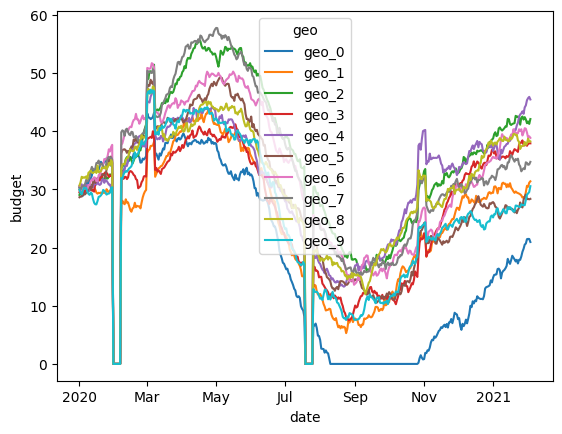

In [135]:
data.budget.plot.line(x="date", hue="geo");

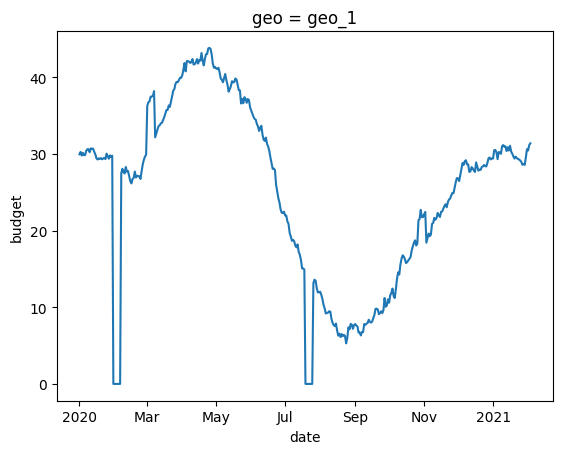

In [136]:
data.budget.sel(geo="geo_1").plot()

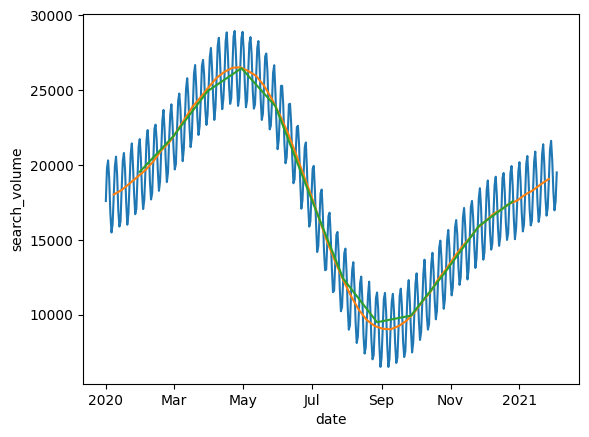

In [137]:
weekly_search_volume = data.search_volume.mean('geo').rolling(date=7, center=True).mean()[::7]
monthly_search_volume = data.search_volume.mean('geo').rolling(date=31, center=True).mean()[::30]
data.search_volume.mean('geo').plot()
weekly_search_volume.plot()
monthly_search_volume.plot()

In [138]:
import preliz as pz

In [ ]:
pz.Exponential(4).plot_pdf()

TypeError: Exponential.__init__() got an unexpected keyword argument 'scale'

In [223]:
HSGP?

Init signature:
HSGP(
    *,
    m: int,
    X: Union[Annotated[pytensor.tensor.variable.TensorVariable, InstanceOf()], Annotated[numpy.ndarray, InstanceOf()], NoneType] = None,
    X_mid: float | None = None,
    dims: str | collections.abc.Sequence[str | None],
    ls: Union[Annotated[pymc_marketing.prior.Prior, InstanceOf()], float],
    eta: Union[Annotated[pymc_marketing.prior.Prior, InstanceOf()], float],
    L: Annotated[float, Gt(gt=0)],
    centered: bool = False,
    drop_first: bool = True,
    cov_func: pymc_marketing.mmm.hsgp.CovFunc = <CovFunc.ExpQuad: 'expquad'>,
) -> None
Docstring:     
HSGP component.

Examples
--------
Literature recommended HSGP configuration:

.. plot::
    :include-source: True
    :context: reset

    import numpy as np
    import pandas as pd

    import matplotlib.pyplot as plt

    from pymc_marketing.mmm import HSGP

    seed = sum(map(ord, "Out of the box GP"))
    rng = np.random.default_rng(seed)

    n = 52
    X = np.arange(n)

    hsgp 

In [398]:
gp = HSGP(
    m=40,
    ls=10,
    eta=.2,
    L=3*12*4*2, 
    dims=('week')
)

Sampling: [f_hsgp_coefs_offset]


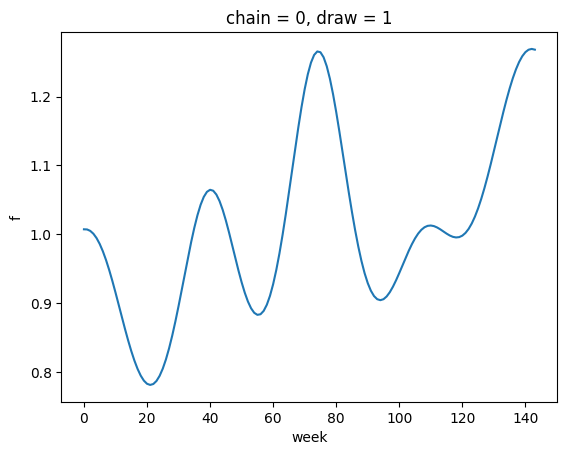

In [399]:
np.exp(gp.register_data(np.arange(0, 3*12*4)).sample_prior(coords={'week':np.arange(0, 3*12*4)})).sel(chain=0, draw=1).f.plot(x='week')

In [426]:
true_rate = np.exp(gp.register_data(np.arange(0, 3*12*4)).sample_prior(coords={'week':np.arange(0, 3*12*4)})).sel(chain=0, draw=1).f

Sampling: [f_eta, f_hsgp_coefs_offset, f_ls]


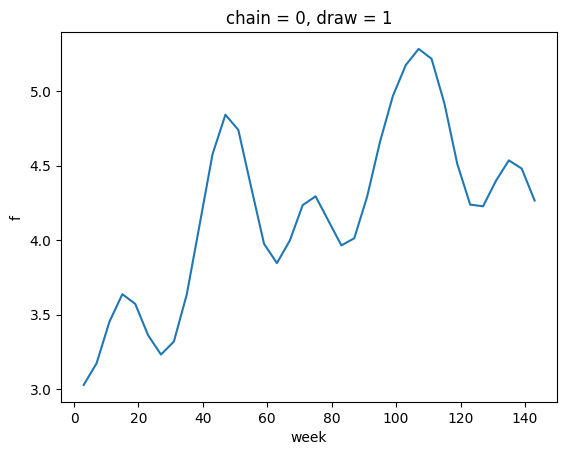

In [427]:
true_rate.rolling(week=4, ).sum()[3::4].plot(x='week')

Sampling: [f_eta, f_hsgp_coefs_offset, f_ls]


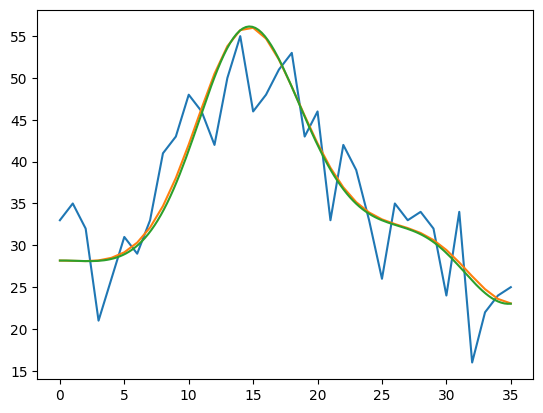

In [429]:
rng = np.random.default_rng(42)
#true_rate = np.exp(rng.normal(0, .1, 3*12*4).cumsum() + 4)
true_rate = np.exp(gp.register_data(np.arange(0, 3*12*4)).sample_prior(coords={'week':np.arange(0, 3*12*4)})).sel(chain=0, draw=1).f
true_rate = true_rate.values*np.exp(2)
test_points = batched_convolution(true_rate, np.array([1, 1, 1, 1]))[3::4].eval()
test_obs = rng.poisson(test_points)
plt.plot(test_obs)
plt.plot(test_points)
plt.plot(np.linspace(0, 35, 3*12*4), true_rate*4)

array([ 3,  7,  4, 11,  8,  4,  5,  8,  9,  7,  5, 10, 10,  6,  6,  4,  6,
        7,  6,  9,  5, 11,  5,  6,  2,  5,  6,  5, 11,  9, 10, 12,  9,  9,
        8, 10, 15,  8, 12,  7, 11,  8,  6, 13, 15, 14,  9,  5, 15,  7, 16,
       14, 21, 14,  9, 13,  9, 11, 13, 15, 13, 15, 14, 15, 16, 15, 17, 13,
       12, 19, 13, 11, 12,  5, 10, 10, 16,  7,  6, 14, 13,  9, 11,  6,  9,
        7, 11, 14,  6,  7, 19,  9,  7, 10,  9,  7, 13,  3, 12,  9, 14,  4,
        5,  5,  2,  2,  9,  7,  3,  4,  6, 13,  3,  6,  7,  7,  6, 12,  5,
        9, 13,  7,  9,  6,  7,  5,  9,  6,  7,  6,  6,  6,  9,  7,  6,  8,
        9,  4,  7,  7, 11,  8,  4,  6])

In [433]:
sales = true_rate*4 + np.random.normal(0, 4, 3*12*4)

In [ ]:
np.corr

In [453]:
np.corrcoef(true_rate, sales)

array([[1.        , 0.92427108],
       [0.92427108, 1.        ]])

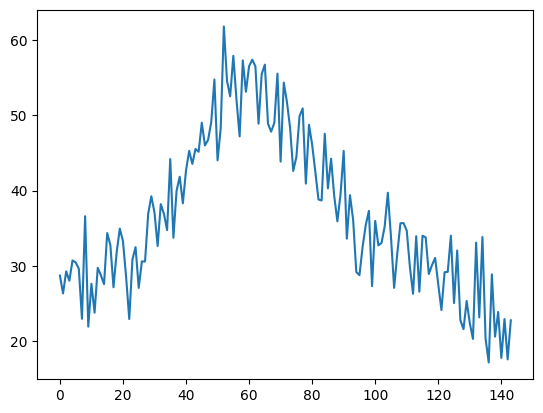

In [434]:
plt.plot(sales)

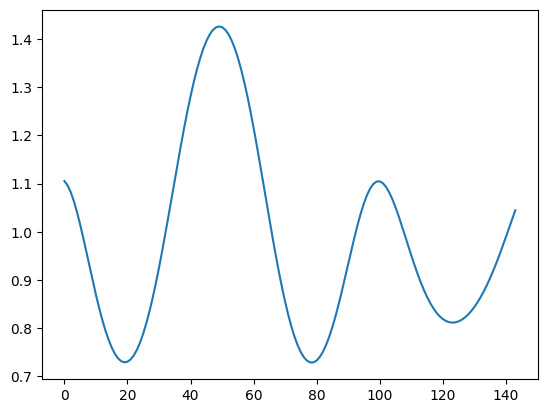

In [403]:
plt.plot(true_rate)

In [444]:

gp = HSGP(
    m=60,
    ls=Prior("Exponential", lam=1/10),
    eta=Prior("Exponential", lam=3),
    L=12*3*4*2,
    dims=('week')
)

with pm.Model() as m:
    # lambda_mu = pm.Gamma("lambda_mu", alpha=2, beta=1)
    #daily_lambda = pm.Exponential("weekly_lambda", lam=lambda_mu, shape=(12), dims=('month'))
    data = pm.Data('time', np.arange(0, 12*4*3), dims='week')
    unobserved_process = gp.register_data(data).create_variable("weekly_lambda_")
    base_rate = pm.Normal('base_rate',mu=0, sigma=4)
    noise_scale = pm.Exponential('noise_scale', 1)
    #noise = 0pm.Normal('noise', 0, noise_scale, dims=('week'))
    beta = pm.Normal('beta', mu=0, sigma=10)
    

    w = pm.Deterministic("weekly_lambda", np.exp(unobserved_process+noise+base_rate))
    sales_est = pm.Deterministic("sales_est", w*beta)
    sales_obs = pm.Normal("sales_obs", mu=sales_est, sigma=noise_scale, observed=sales, dims=('week'))
    #unobserved_process = pm.Gamma('weekly_lambda', alpha=5, beta=.4, dims=('week'))
    test = batched_convolution(w, np.array([1, 1, 1, 1]))[3::4]
    monthly_process = pm.Poisson("monthly_observed", mu=test, observed=test_obs, shape=(36), dims='month')
    trace = pm.sample(1000, tune=1000, target_accept=.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [weekly_lambda__eta, weekly_lambda__ls, weekly_lambda__hsgp_coefs_offset, base_rate, noise_scale, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 46 seconds.
There were 6 divergences after tuning. Increase `target_accept` or reparameterize.


In [445]:
with m:
    pp_trace = pm.sample_posterior_predictive(trace)

Sampling: [monthly_observed, sales_obs]


Output()

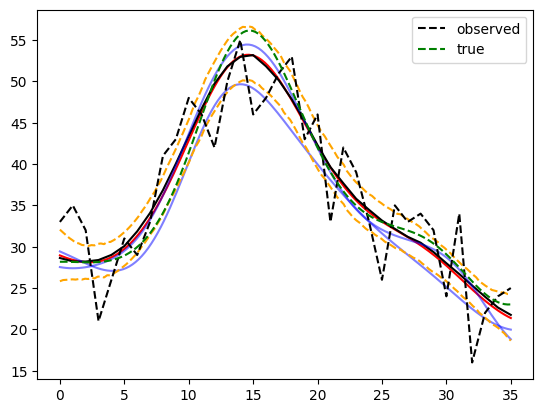

In [446]:

hdi = pm.hdi(trace.posterior['weekly_lambda']*4)
t = np.linspace(0, 35, 3*12*4)
plt.plot(t, trace.posterior['weekly_lambda'].mean(('chain', 'draw')).values*4, c='r')
plt.plot(pp_trace.posterior_predictive['monthly_observed'].mean(('chain', 'draw')).values, c='k')
plt.plot(t, trace.posterior['weekly_lambda'].sel(chain=0, draw=0).values*4, c='b', alpha=.5)
plt.plot(t, trace.posterior['weekly_lambda'].sel(chain=1, draw=2).values*4, c='b', alpha=.5)
plt.plot(t, hdi.sel(hdi='lower').weekly_lambda.values, linestyle='--', c='orange')

plt.plot(t, hdi.sel(hdi='higher').weekly_lambda.values, linestyle='--', c='orange')
plt.plot(test_obs, linestyle='--', label='observed', c='k')
plt.plot(t, 4*true_rate, linestyle='--', label='true', c='g')
plt.legend()


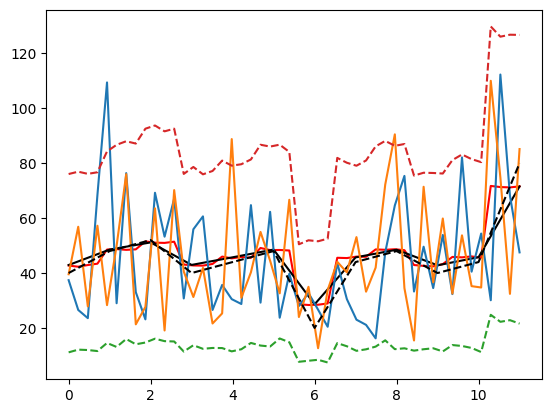

In [217]:
# trace.posterior['weekly_lambda'].stack(time=('week', 'month')).mean(('chain', 'draw')).plot(x='time')

hdi = pm.hdi(trace.posterior['weekly_lambda'].stack(time=('month', 'week'))*4, hdi_prob=0.95)
t = np.linspace(0, 11, 12*4)
plt.plot(t, trace.posterior['weekly_lambda'].stack(time=('month', 'week')).mean(('chain', 'draw')).values*4, c='r')
plt.plot(pp_trace.posterior_predictive['monthly_observed'].mean(('chain','draw')).values, c='k')
plt.plot(t, trace.posterior['weekly_lambda'].stack(time=('month', 'week')).sel(chain=0, draw=0).values*4)
plt.plot(t, trace.posterior['weekly_lambda'].stack(time=('month', 'week')).sel(chain=1, draw=2).values*4)
plt.plot(t, hdi.sel(hdi='lower').weekly_lambda.values, linestyle='--')

plt.plot(t, hdi.sel(hdi='higher').weekly_lambda.values, linestyle='--')
plt.plot(np.array([10, 12, 13, 10, 11, 12, 5, 11, 12, 10, 11, 20])*4, linestyle='--', label='observed', c='k')

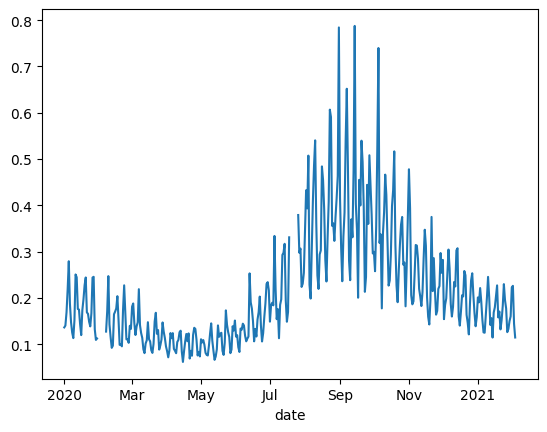

In [44]:
(data.budget.sum("geo")/data.observed_clicks.sum("geo")).plot.line(x="date")

In [144]:
batched_convolution(np.array([2, 2, 2,2, 6, 6, 6, 6]), np.array([1/4, 1/4,1/4, 1/4]))[3::4].eval()

array([2., 6.])

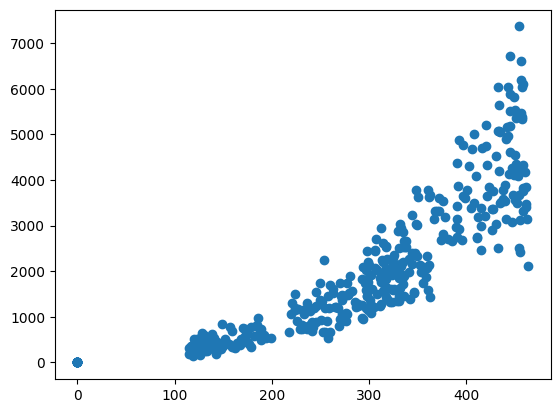

In [325]:
plt.scatter(data.budget.sum("geo").values, (data.observed_clicks.sum("geo")).values)

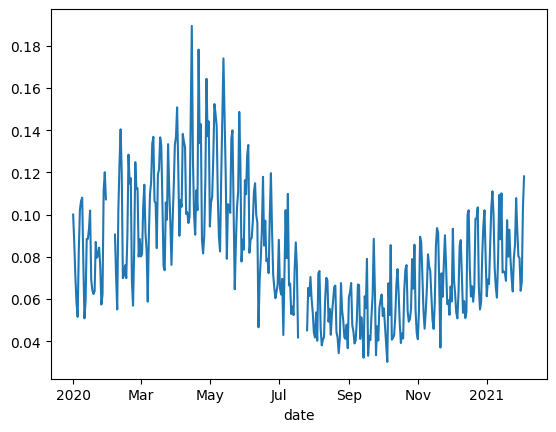

In [326]:
(data.observed_clicks.sum("geo") / data.impressions.sum("geo")).plot()

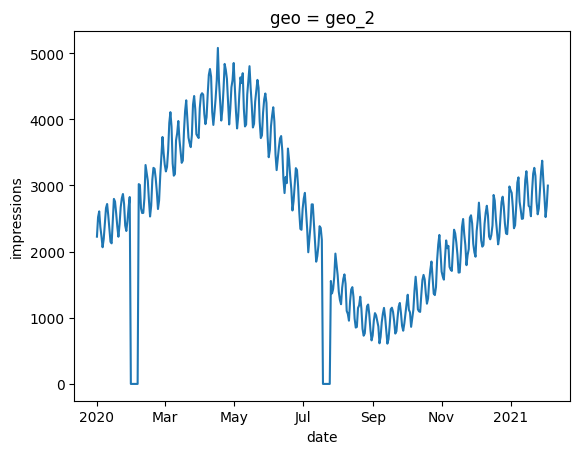

In [327]:
data.impressions.sel(geo="geo_2").plot.line(x="date");

In [328]:
## Prior for long-term periodicity
ls_long_periodic = Prior("Gamma", alpha=1, beta=1/5)
scale_long_periodic = Prior("Exponential", lam=1/100.0)
long_periodic = HSGPWrapper(
    HSGPPeriodic(
    m=40,
    ls=ls_long_periodic,
    scale=scale_long_periodic,
    dims=('date', 'geo'),
    period=365 # yearly
), "long_term_periodic")

## Short-term periodicity for search volume assume similar across geo
weekly_periodic = FourierWrapper(
    WeeklyFourier(
    n_order=3,
    prefix='weekly_search_volume',
    ), 
    dims=('date',),
    name="weekly_periodic"
)

daily_geo_shocks_search_volume = PriorWrapper(
    Prior(
        "Normal", 
        mu=0, 
        sigma=Prior("HalfCauchy", beta=1), 
        dims=('date', 'geo')
    ),
    "daily_geo_shocks_search_volume"
)

base_volume = PriorWrapper(
    Prior(
        "Normal",
        mu=Prior("Normal", mu=15000, sigma=1000),
        sigma=Prior("HalfNormal", sigma=500),
        dims=('geo',)
    ),
    'base_volume'
)

time_data = DataWrapper('time', dims=('date'))

ls_short_periodic = Prior("Gamma", alpha=1, beta=1/30)
scale_short_periodic = Prior("Exponential", lam=1)

short_periodic_ctr= HSGPWrapper(
    HSGPPeriodic(
    m=40,
    ls=ls_long_periodic,
    scale=scale_long_periodic,
    dims=('date', 'geo'),
    period=7 # weekly
), "short_term_periodic_ctr")

ls_long_periodic_ctr = Prior("Gamma", alpha=1, beta=1/5)
scale_long_periodic_ctr = Prior("Exponential", lam=1)
long_periodic_ctr = HSGPWrapper(
    HSGPPeriodic(
    m=40,
    ls=ls_long_periodic_ctr,
    scale=scale_long_periodic_ctr,
    dims=('date', 'geo'),
    period=365 # yearly
), "long_term_periodic_ctr")

ctr_season = (
    short_periodic_ctr 
    + long_periodic_ctr 
    + PriorWrapper(Prior("Normal", mu=0, sigma=1), "season_ctr"))

search_volume_lam = (
    long_periodic 
    + weekly_periodic
    + base_volume
    + daily_geo_shocks_search_volume
    )(time_data)


def search_volume_to_imps(search_volume, budget, model: pm.Model | None= None):
    model = pm.modelcontext(model)
    budget_data = DataWrapper('budget', dims=('date', 'geo'))
    with model:
        multiplier = pm.Beta("search_volume_to_imps", alpha=0.5, beta=0.5)
        competitor_pressure= pm.HalfCauchy("competitor_pressure", beta=1)

        impression_rate = pm.Deterministic("impression_rate", multiplier * hill(budget_data.apply(budget), competitor_pressure, 1.0), dims=('date', 'geo'))

        impressions = pm.Binomial("impressions", n=search_volume, p=impression_rate, dims=('date', 'geo'))
        return impressions

def imps_to_clicks(impressions, season, time_data, model: pm.Model | None= None):

    model = pm.modelcontext(model)

    with model:
        
        ctr_rate = ctr_season.apply(model['time'])
        click_rate = pm.Deterministic('click_rate', pt.sigmoid(ctr_rate), dims=('date', 'geo'))
        clicks = pm.Binomial("clicks", n=impressions, p=click_rate, dims=('date', 'geo'))
        return clicks

In [329]:
coords = {
    "date": data.date.values[:100],
    "geo": data.geo.values
}
with pm.Model(coords=coords) as search_volume_model:
    search_volume = search_volume_lam.apply(data['time'].values[:100])
    search_volume_obs = pm.Poisson("search_volume_obs", mu=pt.softplus(search_volume), dims=('date', 'geo'))

    impressions = search_volume_to_imps(search_volume_obs, data.budget.values[:100])
    clicks = imps_to_clicks(impressions, search_volume_model['long_term_periodic'], data['time'].values[:100])

with search_volume_model:
    search_volume_trace_prior = pm.sample_prior_predictive(1000)

def partial_observe(model, obs_data, input_data, coords, target_accept=.96):
    with pm.observe(model, obs_data):
        pm.set_data(input_data, coords=coords)
        trace = pm.sample(1000, tune=1000, nuts_sampler='nutpie', target_accept=target_accept)
    return trace

search_volume_trace = partial_observe(
    search_volume_model, 
    {'search_volume_obs': data.search_volume.values[:100],
    'impressions': data.impressions.values[:100],
    'clicks': data.observed_clicks.values[:100]}, 
    {'time': data['time'].values[:100],
    'budget': data.budget.values[:100]}, 
    coords)

Sampling: [base_volume, base_volume_mu, base_volume_sigma, clicks, competitor_pressure, daily_geo_shocks_search_volume, daily_geo_shocks_search_volume_sigma, impressions, long_term_periodic_ctr_hsgp_coefs_offset, long_term_periodic_ctr_ls, long_term_periodic_ctr_scale, long_term_periodic_hsgp_coefs_offset, long_term_periodic_ls, long_term_periodic_scale, search_volume_obs, search_volume_to_imps, season_ctr, short_term_periodic_ctr_hsgp_coefs_offset, short_term_periodic_ctr_ls, short_term_periodic_ctr_scale, weekly_search_volume_beta]


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,4,0.02,1023
,2000,0,0.02,255
,2000,0,0.02,255
,2000,0,0.03,127


In [330]:
pm.summary(search_volume_trace, var_names=["search_volume_to_imps", "competitor_pressure"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
search_volume_to_imps,0.251,0.002,0.248,0.254,0.000,0.00,569.0,739.0,1.01
competitor_pressure,30.334,0.425,29.562,31.163,0.018,0.01,556.0,739.0,1.01


In [331]:
search_volume_trace_200 = partial_observe(
    search_volume_model, 
    {'search_volume_obs': data.search_volume.values[:200],
    'impressions': data.impressions.values[:200],
    'clicks': data.observed_clicks.values[:200]}, 
    {'time': data['time'].values[:200],
    'budget': data.budget.values[:200]}, 
    {"date": data.date.values[:200], "geo": data.geo.values})

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,2,0.03,127
,2000,0,0.03,127
,2000,9,0.03,255
,2000,8,0.03,255


In [332]:
with search_volume_model: #pm.observe(search_volume_model, {'search_volume_obs': data.search_volume.values}):
    pm.set_data({'time': data.time.values, 'budget': data.budget.values}, coords={'date': data.date.values})
    search_volume_trace_posterior = pm.sample_posterior_predictive(search_volume_trace)

Sampling: [clicks, daily_geo_shocks_search_volume, impressions, search_volume_obs]


Output()

/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation clicks
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation impressions
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation search_volume_obs
  warnings.warn(f"Could not extract data from symbolic observation {obs}")


In [333]:
with search_volume_model: #pm.observe(search_volume_model, {'search_volume_obs': data.search_volume.values}):
    pm.set_data({'time': data.time.values, 'budget': data.budget.values}, coords={'date': data.date.values})
    search_volume_trace_posterior_200 = pm.sample_posterior_predictive(search_volume_trace_200)

Sampling: [clicks, daily_geo_shocks_search_volume, impressions, search_volume_obs]


Output()

/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation clicks
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation impressions
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation search_volume_obs
  warnings.warn(f"Could not extract data from symbolic observation {obs}")


<>:3: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:3: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
/var/folders/nw/92nd031j7p5d2bs8grpysp4w0000gn/T/ipykernel_59581/3614942695.py:3: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if var_name is 'clicks':


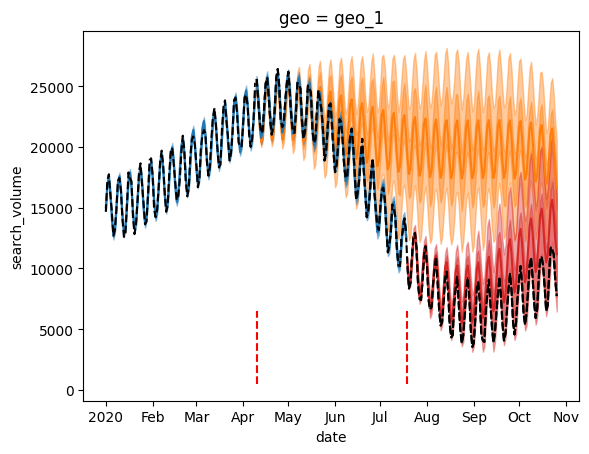

In [334]:
#search_volume_trace.posterior["long_term_periodic+weekly_periodic"].sum("geo").mean(['chain', 'draw']).plot.line(x="date")
def plot_posterior_hdi(pp_trace, var_name, coords, geo="geo_1", date_range=slice(None), c='b'):
    if var_name is 'clicks':
        data_name = "observed_clicks"
    else:
        data_name = var_name
    mean = pp_trace[var_name].sel(geo=geo).isel(date=date_range).mean(['chain', 'draw'])
    hdi = pm.hdi(pp_trace[var_name].sel(geo=geo).isel(date=date_range), hdi_prob=0.95)
    hdi_low = pm.hdi(pp_trace[var_name].sel(geo=geo).isel(date=date_range), hdi_prob=0.60)
    mean.plot.line(x="date", c=c)
    plt.fill_between(
        hdi.date.values,
        hdi[var_name].sel(hdi="lower"),
        hdi[var_name].sel(hdi="higher"),
        alpha=0.4,
        color=c
    )
    plt.fill_between(
        hdi_low.date.values,
        hdi_low[var_name].sel(hdi="lower"),
        hdi_low[var_name].sel(hdi="higher"),
        alpha=0.4,
        color=c
    )
    data[data_name.replace("_obs", "")].sel(geo=geo).isel(date=date_range).plot.line(x="date", c='k', ls='--')
plot_posterior_hdi(search_volume_trace_posterior.posterior_predictive, "search_volume_obs", coords, date_range=slice(100), c='C0')
plot_posterior_hdi(search_volume_trace_posterior.posterior_predictive, "search_volume_obs", coords, date_range=slice(100, 300), c='C1')
plt.vlines(search_volume_trace_posterior.posterior_predictive.date.values[100], 500, 6500, color='r', ls='--')
plot_posterior_hdi(search_volume_trace_posterior_200.posterior_predictive, "search_volume_obs", coords, date_range=slice(100, 200), c='C0')
plt.vlines(search_volume_trace_posterior.posterior_predictive.date.values[200], 500, 6500, color='r', ls='--')
plot_posterior_hdi(search_volume_trace_posterior_200.posterior_predictive, "search_volume_obs", coords, date_range=slice(200, 300), c='C3')

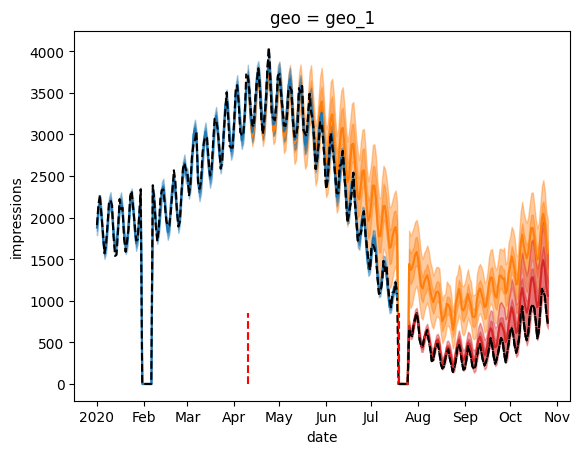

In [335]:
plot_posterior_hdi(search_volume_trace_posterior.posterior_predictive, "impressions", coords, date_range=slice(100), c='C0')
plot_posterior_hdi(search_volume_trace_posterior.posterior_predictive, "impressions", coords, date_range=slice(100, 300), c='C1')
plt.vlines(search_volume_trace_posterior.posterior_predictive.date.values[100], 0, 850, color='r', ls='--')
plot_posterior_hdi(search_volume_trace_posterior_200.posterior_predictive, "impressions", coords, date_range=slice(100, 200), c='C0')
plt.vlines(search_volume_trace_posterior.posterior_predictive.date.values[200], 0, 850, color='r', ls='--')
plot_posterior_hdi(search_volume_trace_posterior_200.posterior_predictive, "impressions", coords, date_range=slice(200, 300), c='C3')

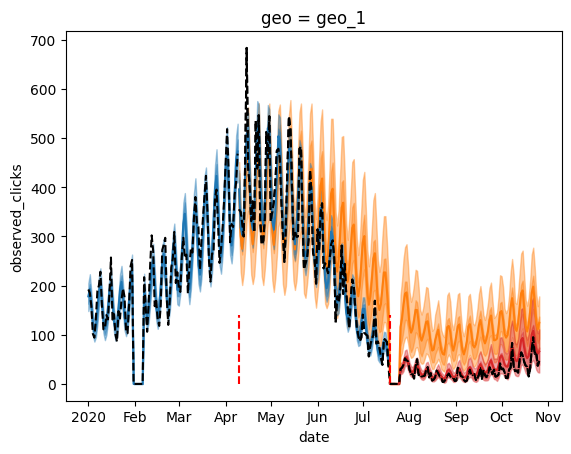

In [336]:
plot_posterior_hdi(search_volume_trace_posterior.posterior_predictive, "clicks", coords, date_range=slice(100), c='C0')
plot_posterior_hdi(search_volume_trace_posterior.posterior_predictive, "clicks", coords, date_range=slice(100, 300), c='C1')
plt.vlines(search_volume_trace_posterior.posterior_predictive.date.values[100], 0, 140, color='r', ls='--')
plot_posterior_hdi(search_volume_trace_posterior_200.posterior_predictive, "clicks", coords, date_range=slice(100, 200), c='C0')
plt.vlines(search_volume_trace_posterior.posterior_predictive.date.values[200], 0, 140, color='r', ls='--')
plot_posterior_hdi(search_volume_trace_posterior_200.posterior_predictive, "clicks", coords, date_range=slice(200, 300), c='C3')

In [337]:
with search_volume_model: #pm.observe(search_volume_model, {'search_volume_obs': data.search_volume.values}):
    pm.set_data({'time': data.time.values, 'budget': 2*data.budget.values}, coords={'date': data.date.values})
    search_volume_trace_posterior_double = pm.sample_posterior_predictive(search_volume_trace_200)

Sampling: [clicks, daily_geo_shocks_search_volume, impressions, search_volume_obs]


Output()

/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation clicks
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation impressions
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation search_volume_obs
  warnings.warn(f"Could not extract data from symbolic observation {obs}")


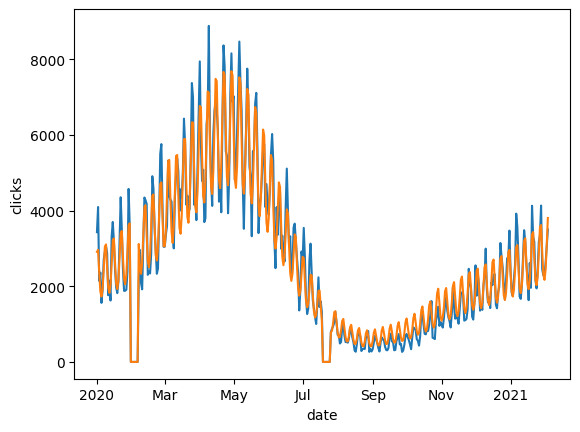

In [346]:
generate_data_search_data(budget=2*data.budget, seed=42).observed_clicks.sum("geo").plot()
search_volume_trace_posterior_double.posterior_predictive.clicks.sum("geo").mean(['chain', 'draw']).plot.line(x="date")


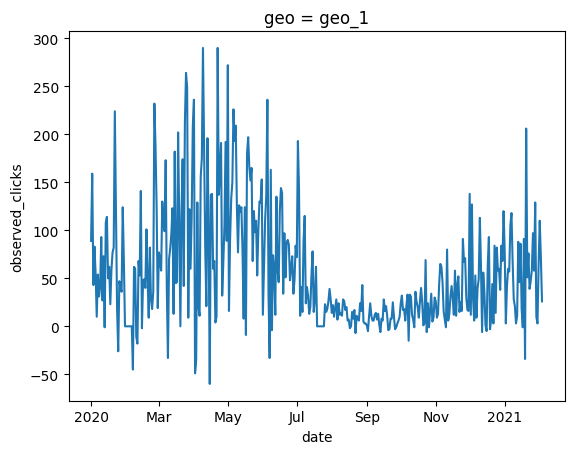

In [341]:
double_budget = generate_data_search_data(budget=2*data.budget)
double_budget_effect = double_budget.observed_clicks-data.observed_clicks
double_budget_effect.sel(geo='geo_1').plot()

In [342]:
estimated_effect = (search_volume_trace_posterior_double.posterior_predictive.clicks - search_volume_trace_posterior_200.posterior_predictive.clicks).to_dataset()

(array([  14.,   73.,  277.,  707., 1118.,  958.,  597.,  192.,   58.,
           6.]),
 array([14518. , 15571.6, 16625.2, 17678.8, 18732.4, 19786. , 20839.6,
        21893.2, 22946.8, 24000.4, 25054. ]),
 <BarContainer object of 10 artists>)

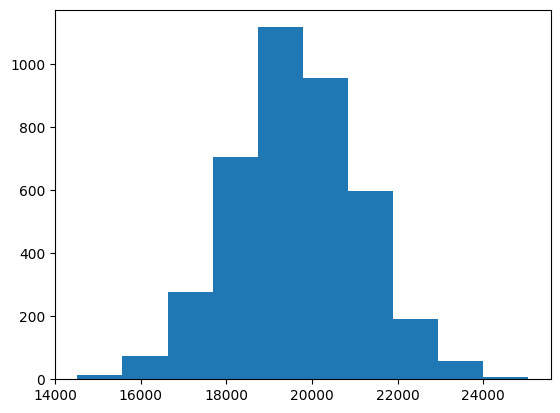

In [343]:
plt.hist((double_budget_effect.isel(date=slice(0, 200)).sum()-estimated_effect.isel(date=slice(0, 200)).sum(('date', 'geo')).clicks.stack(sample=('chain', 'draw'))))

In [253]:
pm.summary(search_volume_trace_200, var_names=['competitor_pressure', 'search_volume_to_imps'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
competitor_pressure,30.048,0.474,29.137,30.903,0.025,0.012,355.0,654.0,1.01
search_volume_to_imps,0.250,0.002,0.247,0.253,0.000,0.000,352.0,707.0,1.01


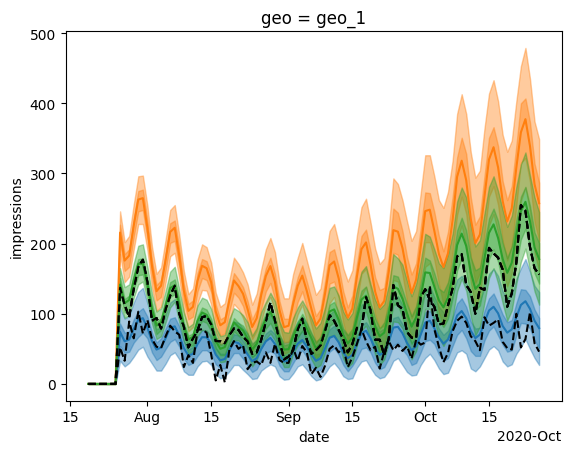

In [258]:
plot_posterior_hdi(estimated_effect, "impressions", coords, date_range=slice(200, 300), c='C0')
plot_posterior_hdi(search_volume_trace_posterior_double.posterior_predictive, "impressions", coords, date_range=slice(200, 300), c='C1')
plot_posterior_hdi(search_volume_trace_posterior_200.posterior_predictive, "impressions", coords, date_range=slice(200, 300), c='C2')
double_budget_effect.sel(geo="geo_1").isel(date=slice(200, 300)).plot.line(x="date", c='k', ls='--')

In [ ]:
# long = HSGP(
#     m=40,
#     L=len(data['time'].values)*1.5,
#     ls=Prior('Gamma', alpha=2, beta=1/3),
#     eta=Prior("Exponential", lam=1),
#     dims=("date", "geo")
# )

long_periodic = HSGPPeriodic(
    m=40,
    ls=Prior("Gamma", alpha=1, beta=1 / 5),
    scale=Prior("Exponential", lam=1 / 100.0),
    dims=("date", "geo"),
    period=365,
)

yearly_seasonality = YearlyFourier(n_order=3, prefix="yearly_trend", dims=("date"))
weekly_seasonality = WeeklyFourier(n_order=3, prefix="weekly_trend", dims=("date",))

train_growing_window_data = xr.Dataset(
    {
        f"slice_{i}": (data.isel(date=slice(0, i)).to_dataarray())
        for i in range(40, 400, 40)
    }
    | {"full": data.to_dataarray()}
)

train_data = data.isel(date=slice(0, 365))
test_data = data.isel(date=slice(35, None))

coords = {"date": data["date"].values, "geo": data['geo'].values}


def model_time_slice(modeling_window):
    long_periodic = HSGPPeriodic(
        m=40,
        ls=Prior("Gamma", alpha=1, beta=1 / 5),
        scale=Prior("Exponential", lam=1 / 100.0),
        dims=("date", "geo"),
        period=365,
    )

    yearly_seasonality = YearlyFourier(n_order=3, prefix="yearly_trend", dims=("date"))
    weekly_seasonality = WeeklyFourier(n_order=3, prefix="weekly_trend", dims=("date",))

    SEARCH_VOLUME = modeling_window.sel(variable="search_volume").dropna(dim="date")

    TIME = modeling_window.sel(variable="time").dropna(dim="date").mean(dim="geo")

    WINDOW_MEAN = SEARCH_VOLUME.mean(...).item()
    WINDOW_STD = SEARCH_VOLUME.std(...).item()
    coords = {"date": SEARCH_VOLUME["date"].values, "geo": SEARCH_VOLUME["geo"].values}
    with pm.Model(coords=coords) as model:
        time_data = pm.Data("time", TIME, dims="date")

        search_volume_data = pm.Data(
            "search_volume_data", SEARCH_VOLUME, dims=("date", "geo")
        )

        base_rate = pm.Normal("base_rate", mu=WINDOW_MEAN, sigma=WINDOW_STD)
        base_rate_sigma = pm.HalfNormal("base_rate_sigma", sigma=100)
        base_rate_geo = pm.Normal(
            "base_rate_geo", mu=base_rate, sigma=base_rate_sigma, dims="geo"
        )

        search_long_trend = long_periodic.register_data(time_data).create_variable(
            "search_long_trend"
        )

        # search_long_trend = pm.Deterministic(
        # 'search_long_trend',
        # yearly_seasonality.apply(time_data), dims="date")
        search_short_trend = handle_dims(
            pm.Deterministic(
                "weekly_seasonality", weekly_seasonality.apply(time_data), dims="date"
            ),
            "date",
            ("date", "geo"),
        )

        search_volume_lam = pt.softplus(
            search_short_trend + search_long_trend + base_rate_geo
        )

        search_volume = pm.Deterministic(
            "search_volume", search_volume_lam, dims=("date", "geo")
        )

        search_volume = pm.Poisson(
            "search_volume_obs",
            mu=search_volume,
            observed=search_volume_data,
            dims=("date", "geo"),
        )

    return model

In [24]:
models = {
    name: model_time_slice(modeling_window)
    for name, modeling_window in train_growing_window_data.items()
}
traces = {
    name: pm.sample(1000, tune=1000, model=model, nuts_sampler="nutpie")
    for name, model in models.items()
}
# posteriors = {name: pm.sample_posterior_predictive(traces[name], model=models[name], samples=1000) for name in models}

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.08,63
,2000,6,0.08,63
,2000,180,0.08,63
,2000,12,0.08,63


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,8,0.07,63
,2000,5,0.07,63
,2000,11,0.07,63
,2000,2,0.08,63


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,8,0.08,63
,2000,6,0.08,63
,2000,2,0.08,63
,2000,11,0.07,63


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,5,0.07,63
,2000,1,0.09,63
,2000,4,0.08,63
,2000,2,0.08,63


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,47,0.10,63
,2000,3,0.07,63
,2000,4,0.08,63
,2000,1,0.08,63


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.10,127
,2000,6,0.12,31
,2000,8,0.10,63
,2000,18,0.08,63


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,2,0.10,63
,2000,12,0.09,63
,2000,0,0.10,63
,2000,15,0.08,63


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,20,0.13,31
,2000,6,0.12,31
,2000,1,0.12,31
,2000,0,0.14,31


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,4,0.09,63
,2000,14,0.09,63
,2000,0,0.11,31
,2000,10,0.13,31


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.11,31
,2000,5,0.09,63
,2000,6,0.07,63
,2000,24,0.10,3


In [25]:
posteriors = {}
for name in models:
    with models[name]:
        pm.set_data(
            {"time": data["time"], "search_volume_data": data["search_volume"]},
            coords={"date": data["date"].values},
        )
        posteriors[name] = pm.sample_posterior_predictive(
            traces[name], extend_inferencedata=False
        )

Sampling: [search_volume_obs]


Output()

Sampling: [search_volume_obs]


Output()

Sampling: [search_volume_obs]


...

Output()

Sampling: [search_volume_obs]


Output()

Sampling: [search_volume_obs]


Output()

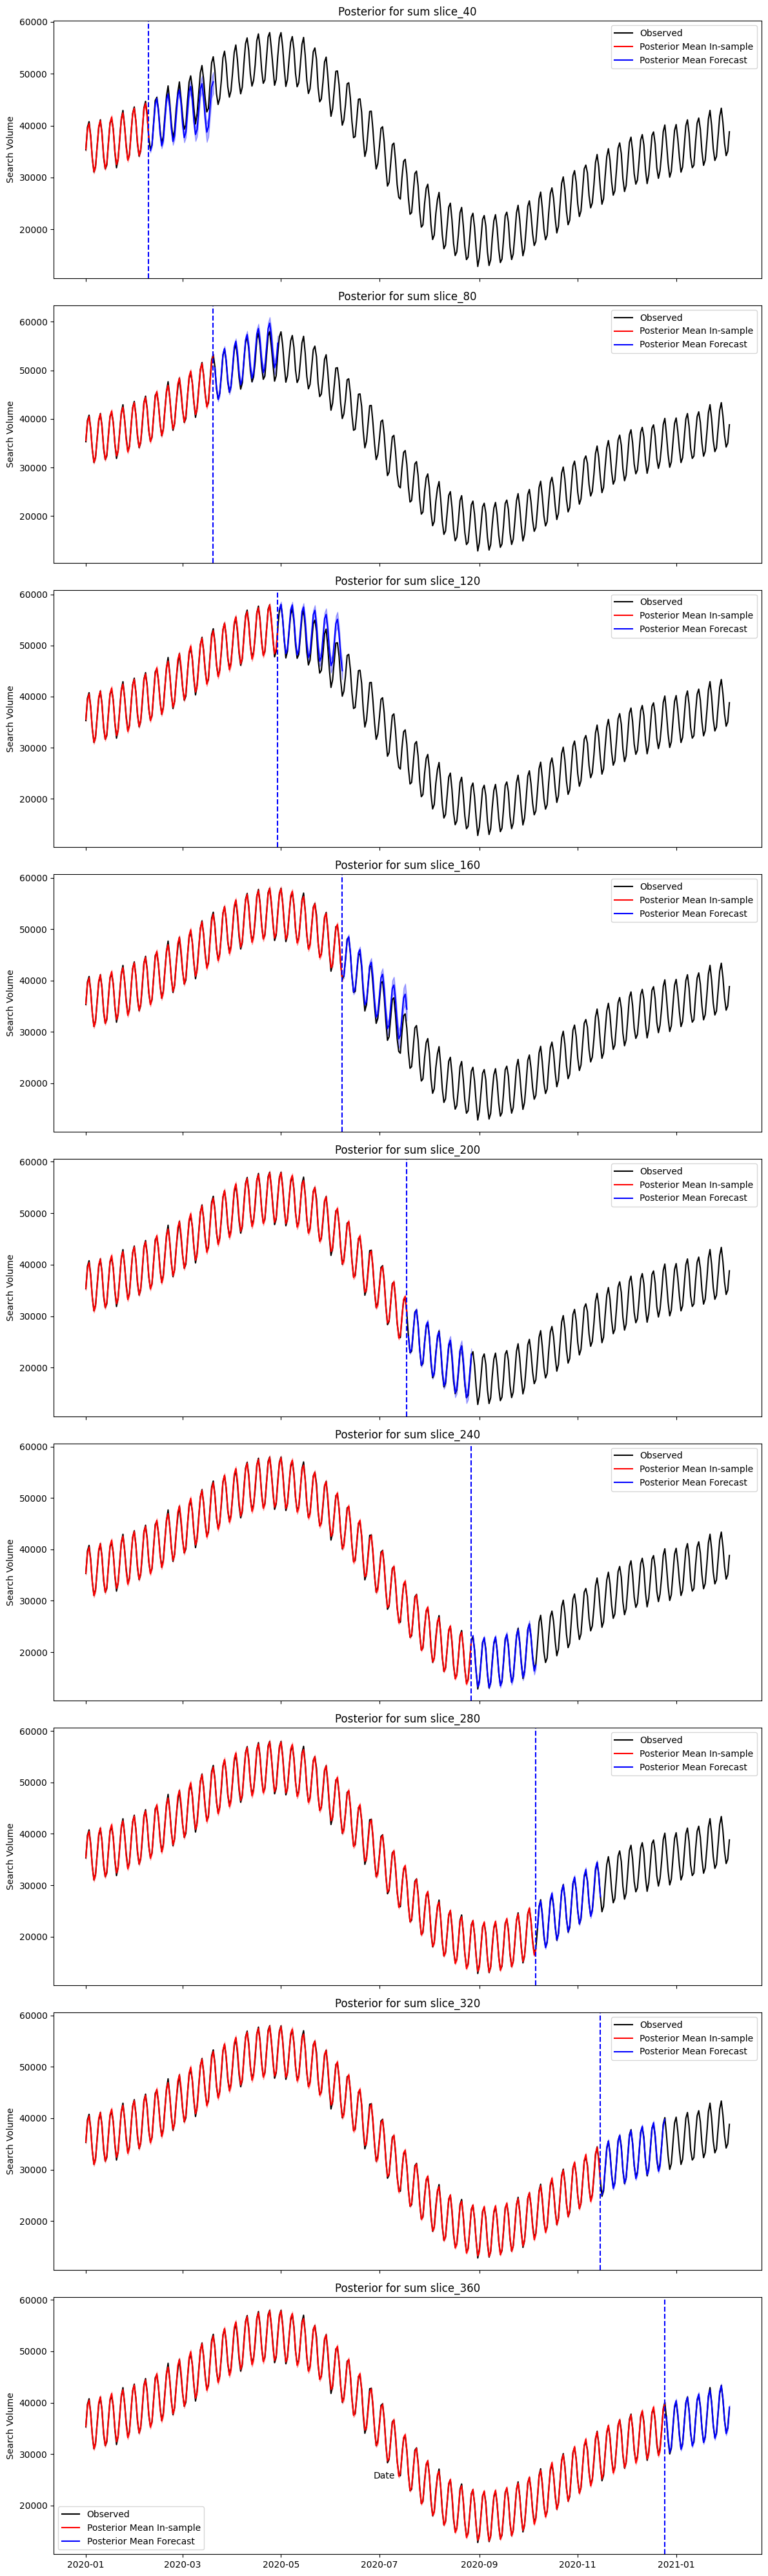

In [27]:
fig, axes = plt.subplots(
    len(posteriors) - 1, 1, figsize=(12, 4 * len(posteriors)), sharex=True
)

GEO = "sum"
# If there's only one slice, axes won't be an array
if len(posteriors) == 1:
    axes = [axes]

for i, (slice_name, posterior) in enumerate(posteriors.items()):
    if slice_name == "full":
        continue

    ax = axes[i]

    # Get the observed data
    if GEO == "sum":
        observed = data["search_volume"].sum(dim="geo")
        slice_len = (
            train_growing_window_data[slice_name]
            .dropna(dim="date")
            .sum(dim="geo")
            .sel(variable="search_volume")
            .shape[0]
        )
        posterior_mean = (
            posterior.posterior_predictive.search_volume_obs.sum("geo")
            .mean(dim=("chain", "draw"))
            .isel(date=slice(slice_len + 40))
        )
        posterior_hdi = pm.hdi(
            posterior.posterior_predictive.search_volume_obs.sum(dim="geo")
        )["search_volume_obs"].isel(date=slice(slice_len + 40))
    else:
        observed = data["search_volume"].sel(geo=GEO)
        slice_len = (
            train_growing_window_data[slice_name]
            .dropna(dim="date")
            .sel(variable="search_volume", geo=GEO)
            .shape[0]
        )
        # Get the posterior mean and HDI
        posterior_mean = (
            posterior.posterior_predictive.search_volume_obs.mean(dim=("chain", "draw"))
            .sel(geo=GEO)
            .isel(date=slice(slice_len + 40))
        )
        posterior_hdi = pm.hdi(
            posterior.posterior_predictive.search_volume_obs.sel(geo=GEO)
        )["search_volume_obs"].isel(date=slice(slice_len + 40))

    posterior_mean_insample = posterior_mean.isel(date=slice(0, slice_len))
    posterior_hdi_insample = posterior_hdi.isel(date=slice(0, slice_len))
    posterior_mean_oos = posterior_mean.isel(date=slice(slice_len, None))
    posterior_hdi_oos = posterior_hdi.isel(date=slice(slice_len, None))

    # Plot the data
    ax.plot(data["date"], observed, "k-", label="Observed")
    ax.plot(
        posterior_mean_insample.date,
        posterior_mean_insample,
        "r-",
        label="Posterior Mean In-sample",
    )
    ax.plot(
        posterior_mean_oos.date,
        posterior_mean_oos,
        "b-",
        label="Posterior Mean Forecast",
    )

    # Plot the HDI
    ax.fill_between(
        posterior_hdi_insample.date.values,
        posterior_hdi_insample.sel(hdi="lower"),
        posterior_hdi_insample.sel(hdi="higher"),
        color="r",
        alpha=0.3,
    )
    # Plot the HDI
    ax.fill_between(
        posterior_hdi_oos.date.values,
        posterior_hdi_oos.sel(hdi="lower"),
        posterior_hdi_oos.sel(hdi="higher"),
        color="b",
        alpha=0.3,
    )

    # Add slice data boundary line if it's not the full dataset
    if slice_name != "full":
        slice_size = int(slice_name.split("_")[1])
        ax.axvline(data["date"].values[slice_size - 1], color="blue", linestyle="--")

    # Add title and labels
    ax.set_title(f"Posterior for {GEO} {slice_name}")
    ax.set_ylabel("Search Volume")
    ax.legend()

# Add common x-label
fig.text(0.5, 0.04, "Date", ha="center", va="center")
fig.tight_layout()
fig.savefig("search_volume_posterior.png")
plt.show()

In [256]:
class GeneralPrior(Protocol):
    def apply(self, data: xr.DataArray | pt.TensorLike) -> pt.TensorLike:
        pass


class Node(ABC):
    def __init__(self, name: str):
        self.name = name

    @abstractmethod
    def apply(
        self, data: xr.DataArray | pt.TensorLike, model: pm.Model | None = None
    ) -> pt.TensorLike:
        raise NotImplementedError

    def __add__(self, other: GeneralPrior) -> SumNode:
        return SumNode([self, other], name=f"{self.name}+{other.name}")

    def __mul__(self, other: GeneralPrior) -> ProductNode:
        return ProductNode([self, other], name=f"{self.name}*{other.name}")

    def __call__(self, node: GeneralPrior) -> GeneralPrior:
        return AppliedNode(f"{self.name}({node.name})", self, node)


class CombNode(Node):
    def __init__(self, children: list[GeneralPrior], name: str, agg_fn: Callable):
        super().__init__(name)
        self.children = children
        self.agg_fn = agg_fn
        self._dims = tuple(
            set(
                dim for dims in [child._dims for child in self.children] for dim in dims
            )
        )

    def apply(
        self, data: list[xr.DataArray | pt.TensorLike], model: pm.Model | None = None
    ) -> pt.TensorLike:
        model = pm.modelcontext(model)
        assert len(self.children) == len(
            data
        ), "Children and data must be the same length"
        with model:
            self.children[0].apply(data[0])
            for _child, _data in zip(self.children[1:], data[1:]):
                _child.apply(_data)
            self._variable = pm.Deterministic(
                self.name,
                self.agg_fn(
                    [
                        handle_dims(child._variable, child._dims, self._dims)
                        for child in self.children
                    ]
                ),
                dims=self._dims,
            )


class SumNode(CombNode):
    def __init__(self, children: list[GeneralPrior], name: str):
        super().__init__(children, name, sum)


class ProductNode(CombNode):
    def __init__(self, children: list[GeneralPrior], name: str):
        super().__init__(children, name, np.prod)


class AppliedNode(Node):
    def __init__(self, name: str, caller_node: Node, input_node: Node):
        super().__init__(name)
        self._caller_node = caller_node
        self._input_node = input_node
        self._dims = caller_node._dims

    def apply(
        self, data: xr.DataArray | pt.TensorLike, model: pm.Model | None = None
    ) -> pt.TensorLike:
        model = pm.modelcontext(model)

        with model:
            if isinstance(self._caller_node, CombNode):
                data_input = self._input_node.apply(data)
                self._variable = self._caller_node.agg_fn(
                    handle_dims(
                        child.apply(data_input), child._dims, self._caller_node._dims
                    )
                    for child in self._caller_node.children
                )
                return self._variable

            self._variable = self._caller_node.apply(self._input_node.apply(data))
            return self._variable


class HSGPWrapper(Node):
    def __init__(self, gp, name: str):
        super().__init__(name)
        self._gp = gp
        self._dims = gp.dims

    def apply(
        self, data: xr.DataArray | pt.TensorLike | None, model: pm.Model | None = None
    ) -> pt.TensorLike:
        model = pm.modelcontext(model)
        with model:
            self._variable = self._gp.register_data(data).create_variable(self.name)
        return self._variable


class FourierWrapper(Node):
    def __init__(self, fourier, name: str):
        super().__init__(name)
        self._fourier = fourier
        self._dims = fourier.dims

    def apply(
        self, data: xr.DataArray | pt.TensorLike | None, model: pm.Model | None = None
    ) -> pt.TensorLike:
        model = pm.modelcontext(model)
        with model:
            self._variable = self.Deterministic(
                self.name, self._fourier.apply(data), self._dims
            )
        return self._variable


class PriorWrapper(Node):
    def __init__(self, prior, name: str):
        super().__init__(name)
        self._prior = prior
        self._dims = prior.dims

    def apply(
        self,
        data: xr.DataArray | pt.TensorLike | None = None,
        model: pm.Model | None = None,
    ) -> pt.TensorLike:
        model = pm.modelcontext(model)
        with model:
            self._variable = self._prior.create_variable(self.name)
        return self._variable


class DataWrapper(Node):
    def __init__(self, name: str, dims: Tuple[str] | None = None):
        super().__init__(name)
        self._dims = dims

    def apply(
        self, data: xr.DataArray | pt.TensorLike, model: pm.Model | None = None
    ) -> pt.TensorLike:
        model = pm.modelcontext(model)
        with model:
            self._variable = pm.Data(self.name, data, dims=self._dims)
        return self._variable


# class MissingData(Node):
#     def __init__(self, name: str, dims: Tuple[str], prior: GeneralPrior):
#         super().__init__(name)
#         self._dims = dims
#         self._prior = prior

#     def apply(self, data: xr.DataArray|pt.TensorLike, model: pm.Model|None = None) -> pt.TensorLike:
#         model = pm.modelcontext(model)
#         with pm.observe(model, {self._prior.name: data}):
#             self._variable = self._prior.apply()
#         return self._variable

#     def apply(self, data: xr.DataArray|pt.TensorLike, model: pm.Model|None = None) -> pt.TensorLike:
#         model = pm.modelcontext(model)
#         with model:
#             self._variable = pm.Data(self.name, data, dims=self._dims)
#         return self._variable

In [ ]:
prior_gamma = PriorWrapper(Prior("Gamma", alpha=1, beta=1 / 5), "gamma")
long_periodic = HSGPPeriodic(
    m=40,
    ls=Prior("Gamma", alpha=1, beta=1 / 5),
    scale=Prior("Exponential", lam=1 / 100.0),
    dims=("date", "geo"),
    period=365,
)

long_periodic = HSGPWrapper(long_periodic, "long_periodic")

time_data = DataWrapper("time", dims="date")
search_volume_data = DataWrapper("search_volume_data", dims=("date", "geo"))

time_trend = (prior_gamma + long_periodic)(data_node)

sigma = Prior("HalfNormal", sigma=100)

with pm.Model(coords=coords) as model:
    total = time_trend.apply(data["time"].values)
    sig = sigma.create_variable("sigma")
    pm.Normal("total", mu=total, sigma=sig, dims=time_trend._dims)
    prior = pm.sample_prior_predictive(samples=1000)

Sampling: [gamma, long_periodic_hsgp_coefs_offset, long_periodic_ls, long_periodic_scale, sigma, total]


In [ ]:
import dowhy

In [445]:
data.to_dataframe()

search_volume  impressions  observed_clicks  dayofyear  \
date       geo                                                             
2020-01-01 geo_0           3557          668               40          1   
           geo_1           2974          551               39          1   
           geo_2           3672          676               54          1   
           geo_3           4611          845               74          1   
           geo_4           2879          480               33          1   
...                         ...          ...              ...        ...   
2021-02-03 geo_5           3149          584               39         34   
           geo_6           5058         1052               81         34   
           geo_7           4207          808               60         34   
           geo_8           3055          634               38         34   
           geo_9           3937          746               59         34   

                  time      budget  
date       geo                      
2020-01-01 geo_0     0  297.607229  
           geo_1     0  302.578303  
           geo_2     0  308.109369  
           geo_3     0  297.400829  
           geo_4     0  293.337751  
...                ...         ...  
2021-02-03 geo_5   399  293.439306  
           geo_6   399  399.626916  
           geo_7   399  354.953017  
           geo_8   399  366.935983  
           geo_9   399  318.282633  

[4000 rows x 6 columns]

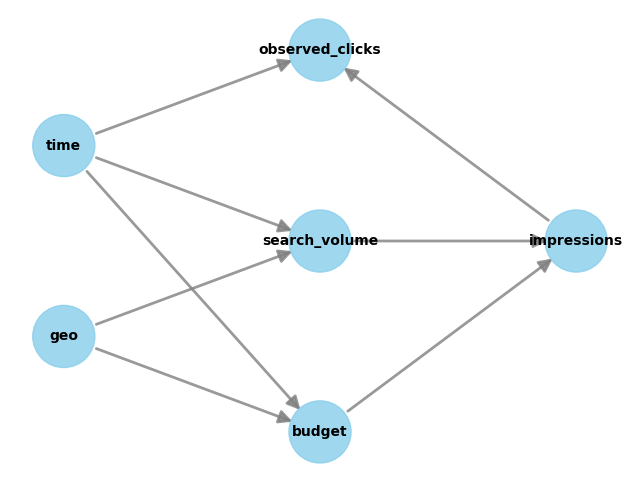

In [446]:
model = dowhy.CausalModel(
    data=data.to_dataframe(),
    graph=causal_graph.replace("\n", " "),
    treatment="budget",
    outcome="observed_clicks",
)
model.view_model()

In [203]:
DEFAULT_PRIORS = {
    "base_search_volume": Prior("Gamma", alpha=100, beta=1 / 5.0),
    "long_search_volume_trend": HSGP(
        m=40,
        L=len(data["time"].values) * 1.5,
        ls=Prior("Gamma", alpha=2, beta=1 / 3),
        eta=Prior("Exponential", lam=1),
        dims=("date", "geo"),
    ),
}

In [402]:
def gen_model(data, priors=None, coords=None):
    if coords is None:
        coords = {key: value.values for key, value in data.coords.items()}

    default_priors = {
        "base_demand": pm_mrk.prior.Prior("Normal", mu=300, sigma=300),
        "weekly_demand_seasonality_order": 4,
        "yearly_demand_seasonality_order": 4,
        "weekly_demand_seasonality": pm_mrk.prior.Prior(
            "Normal", mu=0, sigma=50, dims=("weekly_demand")
        ),
        "yearly_demand_seasonality": pm_mrk.prior.Prior(
            "Normal", mu=0, sigma=150, dims=("yearly_demand")
        ),
        "base_impressions": pm_mrk.prior.Prior("Normal", mu=0, sigma=1),
        "weekly_imp_seasonality_order": 4,
        "yearly_imp_seasonality_order": 4,
        "weekly_imp_seasonality": pm_mrk.prior.Prior(
            "Normal", mu=0, sigma=1, dims=("weekly_imp")
        ),
        "yearly_imp_seasonality": pm_mrk.prior.Prior(
            "Normal", mu=0, sigma=1, dims=("yearly_imp")
        ),
        "base_clicks": pm_mrk.prior.Prior("Normal", mu=0, sigma=1),
        "weekly_click_seasonality_order": 4,
        "yearly_click_seasonality_order": 4,
        "weekly_click_seasonality": pm_mrk.prior.Prior(
            "Normal", mu=0, sigma=1, dims=("weekly_click")
        ),
        "yearly_click_seasonality": pm_mrk.prior.Prior(
            "Normal", mu=0, sigma=1, dims=("yearly_click")
        ),
    }

    if priors is None:
        priors = default_priors
    else:
        priors = {**default_priors, **priors}

    date = data["date"]
    dayofyear = data["dayofyear"]

    weekly_demand_seasonality = pm_mrk.mmm.WeeklyFourier(
        n_order=priors["weekly_demand_seasonality_order"],
        prefix="weekly_demand",
        priors=priors["weekly_demand_seasonality"],
    )
    yearly_demand_seasonality = pm_mrk.mmm.YearlyFourier(
        n_order=priors["yearly_demand_seasonality_order"],
        prefix="yearly_demand",
        priors=priors["yearly_demand_seasonality"],
    )
    weekly_imp_seasonality = pm_mrk.mmm.WeeklyFourier(
        n_order=priors["weekly_imp_seasonality_order"],
        prefix="weekly_imp",
        priors=priors["weekly_imp_seasonality"],
    )
    yearly_imp_seasonality = pm_mrk.mmm.YearlyFourier(
        n_order=priors["yearly_imp_seasonality_order"],
        prefix="yearly_imp",
        priors=priors["yearly_imp_seasonality"],
    )
    weekly_click_seasonality = pm_mrk.mmm.WeeklyFourier(
        n_order=priors["weekly_click_seasonality_order"],
        prefix="weekly_click",
        priors=priors["weekly_click_seasonality"],
    )
    yearly_click_seasonality = pm_mrk.mmm.YearlyFourier(
        n_order=priors["yearly_click_seasonality_order"],
        prefix="yearly_click",
        priors=priors["yearly_click_seasonality"],
    )

    with pm.Model(coords=coords) as model:
        dayofyear = pm.Data("dayofyear", dayofyear, dims=("date",))

        base_demand = priors["base_demand"].create_variable("base_demand")
        weekly_demand_seasonality = weekly_demand_seasonality.apply(dayofyear)
        yearly_demand_seasonality = yearly_demand_seasonality.apply(dayofyear)
        demand = pm.Deterministic(
            "demand",
            pt.math.softplus(
                base_demand + weekly_demand_seasonality + yearly_demand_seasonality
            ),
        )

        obs_demand = pm.Poisson("obs_demand", mu=demand, dims=tuple(data.dims.keys()))

        base_impressions = priors["base_impressions"].create_variable(
            "base_impressions"
        )
        weekly_imp_seasonality = weekly_imp_seasonality.apply(dayofyear)
        yearly_imp_seasonality = yearly_imp_seasonality.apply(dayofyear)
        impressions_rate = pm.Deterministic(
            "impressions_rate",
            pm.math.invlogit(
                base_impressions + weekly_imp_seasonality + yearly_imp_seasonality
            ),
        )

        impressions = pm.Binomial(
            "impressions",
            n=obs_demand,
            p=impressions_rate,
            dims=tuple(data.dims.keys()),
        )

        base_clicks = priors["base_clicks"].create_variable("base_clicks")
        weekly_click_seasonality = weekly_click_seasonality.apply(dayofyear)
        yearly_click_seasonality = yearly_click_seasonality.apply(dayofyear)
        click_rate = pm.Deterministic(
            "click_rate",
            pm.math.invlogit(
                base_clicks + weekly_click_seasonality + yearly_click_seasonality
            ),
        )

        clicks = pm.Binomial(
            "clicks", n=impressions, p=click_rate, dims=tuple(data.dims.keys())
        )

    return model

In [192]:
def train_model(data, samples, priors=None, sampler_kwargs=None):
    if sampler_kwargs is None:
        sampler_kwargs = {}
    model = gen_model(data, priors)
    with pm.observe(
        model,
        {
            "obs_demand": data["search_volume"].values,
            "impressions": data["impressions"].values,
            "clicks": data["observed_clicks"].values,
        },
    ):
        trace = pm.sample(samples, **sampler_kwargs)
    return model, trace

In [233]:
train_test_split = 0.9
n_train = int(n_days * train_test_split)
train_data = data.sel(date=slice(None, date[n_train]))
test_data = data.sel(date=slice(date[n_train], None))

# train_data.loc[5:10, 'clicks'] = np.nan
# train_data.loc[15:20, 'impressions'] = np.nan
# train_data.loc[25:30, 'obs_demand'] = np.nan

model, trace = train_model(train_data, 1000, sampler_kwargs={"nuts_sampler": "nutpie"})

/var/folders/nw/92nd031j7p5d2bs8grpysp4w0000gn/T/ipykernel_11457/1001842126.py:47: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  obs_demand = pm.Poisson('obs_demand', mu=demand, dims=tuple(data.dims.keys()))
/var/folders/nw/92nd031j7p5d2bs8grpysp4w0000gn/T/ipykernel_11457/1001842126.py:54: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  impressions = pm.Binomial('impressions', n=obs_demand, p=impressions_rate, dims=tuple(data.dims.keys()))
/var/folders/nw/92nd031j7p5d2bs8grpysp4w0000gn/T/ipykernel_11457/1001842126.py:61: FutureWarning: The return type of `Dataset.dims` will be changed to ret

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.09,63
,2000,0,0.11,319
,2000,0,0.10,63
,2000,0,0.10,31


In [234]:
def sample_posterior(model, trace, data=None):
    model_copy = pm.model.fgraph.clone_model(model)
    with model_copy:
        if data is not None:
            pm.set_data(
                {"dayofyear": data["dayofyear"].values},
                coords={"date": data["date"].values},
            )

        post_pred = pm.sample_posterior_predictive(trace)
    return post_pred

In [235]:
posterior_train = sample_posterior(model, trace)
posterior_test = sample_posterior(model, trace, data=test_data)

Sampling: [clicks, impressions, obs_demand]


Output()

/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation obs_demand
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation impressions
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation clicks
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
Sampling: [clicks, impressions, obs_demand]


Output()

/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation obs_demand
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation impressions
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation clicks
  warnings.warn(f"Could not extract data from symbolic observation {obs}")


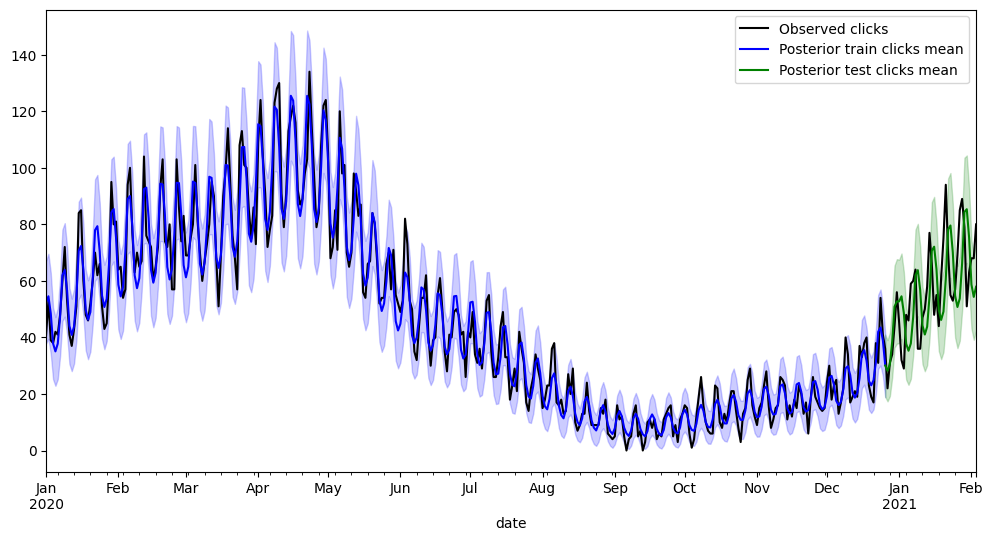

In [238]:
data_with_posterior = data.to_dataframe().reset_index().copy()
data_with_posterior["date"] = pd.to_datetime(data_with_posterior["date"])
data_with_posterior["posterior_train_clicks_mean"] = np.nan
data_with_posterior["posterior_train_clicks_std"] = np.nan
data_with_posterior.loc[:(n_train), "posterior_train_clicks_mean"] = (
    posterior_train.posterior_predictive["clicks"].mean(dim=("chain", "draw")).values
)
data_with_posterior.loc[:(n_train), "posterior_train_clicks_std"] = (
    posterior_train.posterior_predictive["clicks"].std(dim=("chain", "draw")).values
)
data_with_posterior["posterior_test_clicks_mean"] = np.nan
data_with_posterior["posterior_test_clicks_std"] = np.nan
data_with_posterior.loc[n_train:, "posterior_test_clicks_mean"] = (
    posterior_test.posterior_predictive["clicks"].mean(dim=("chain", "draw")).values
)
data_with_posterior.loc[n_train:, "posterior_test_clicks_std"] = (
    posterior_test.posterior_predictive["clicks"].std(dim=("chain", "draw")).values
)

fig, ax = plt.subplots(figsize=(12, 6))
data_with_posterior.plot(
    x="date", y="observed_clicks", ax=ax, label="Observed clicks", c="k"
)
data_with_posterior.plot(
    x="date",
    y="posterior_train_clicks_mean",
    ax=ax,
    label="Posterior train clicks mean",
    c="b",
)
data_with_posterior.plot(
    x="date",
    y="posterior_test_clicks_mean",
    ax=ax,
    label="Posterior test clicks mean",
    c="g",
)
plt.fill_between(
    data_with_posterior["date"].values,
    data_with_posterior["posterior_train_clicks_mean"].values
    - 2 * data_with_posterior["posterior_train_clicks_std"].values,
    data_with_posterior["posterior_train_clicks_mean"].values
    + 2 * data_with_posterior["posterior_train_clicks_std"].values,
    alpha=0.2,
    color="b",
)
plt.fill_between(
    data_with_posterior["date"].values,
    data_with_posterior["posterior_test_clicks_mean"].values
    - 2 * data_with_posterior["posterior_test_clicks_std"].values,
    data_with_posterior["posterior_test_clicks_mean"].values
    + 2 * data_with_posterior["posterior_test_clicks_std"].values,
    alpha=0.2,
    color="g",
)
plt.show()

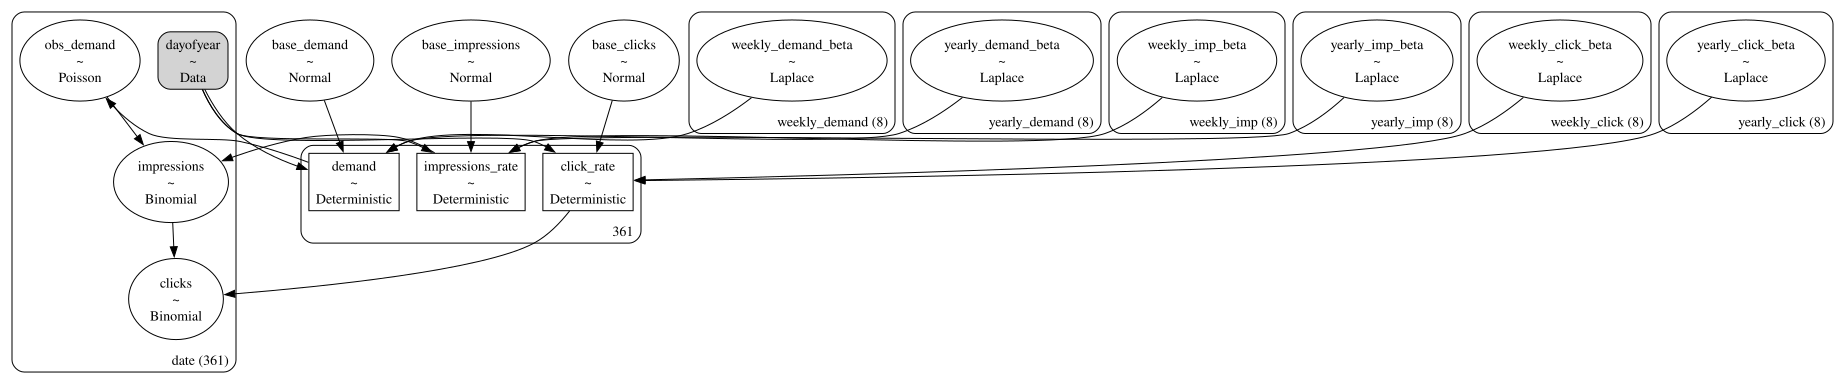

In [241]:
pm.model_to_graphviz(model)

In [240]:
with model:
    prior = pm.sample_prior_predictive()
    trace = pm.sample_posterior_predictive(trace, extend_inferencedata=True)

Sampling: [base_clicks, base_demand, base_impressions, clicks, impressions, obs_demand, weekly_click_beta, weekly_demand_beta, weekly_imp_beta, yearly_click_beta, yearly_demand_beta, yearly_imp_beta]
Sampling: [clicks, impressions, obs_demand]


Output()

/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation obs_demand
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation impressions
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation clicks
  warnings.warn(f"Could not extract data from symbolic observation {obs}")


Text(0.5, 1.0, 'Prior predictive draws for search volume')

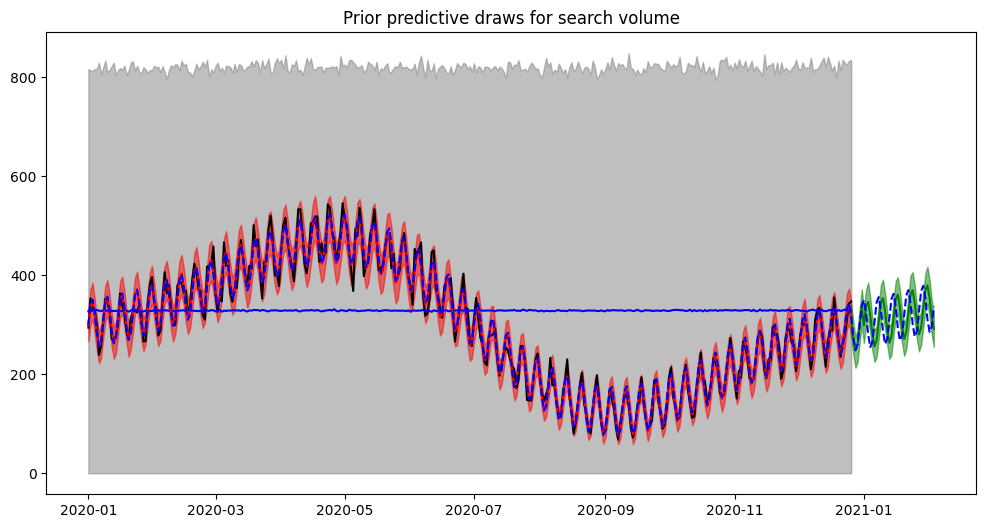

In [247]:
# prior.prior_predictive['search_volume']
plt.figure(figsize=(12, 6))
hdi_prior = pm.hdi(prior.prior["obs_demand"], hdi_prob=0.95)
date = train_data["date"]
plt.fill_between(
    date,
    hdi_prior["obs_demand"].sel(hdi="lower"),
    hdi_prior["obs_demand"].sel(hdi="higher").values,
    color="gray",
    alpha=0.5,
)
plt.plot(date, train_data["search_volume"], color="black")
plt.plot(date, prior.prior["obs_demand"].mean(dim=("chain", "draw")), color="blue")
plt.plot(
    date,
    trace.posterior_predictive["obs_demand"].mean(dim=("chain", "draw")),
    color="red",
)
hdi_posterior = pm.hdi(trace.posterior_predictive["obs_demand"], hdi_prob=0.95)
plt.fill_between(
    date,
    hdi_posterior["obs_demand"].sel(hdi="lower"),
    hdi_posterior["obs_demand"].sel(hdi="higher"),
    color="red",
    alpha=0.5,
)
hdi_posterior_new = pm.hdi(
    posterior_test.posterior_predictive["obs_demand"], hdi_prob=0.95
)
plt.plot(
    hdi_posterior_new["date"],
    posterior_test.posterior_predictive["obs_demand"].mean(dim=("draw", "chain")),
    color="green",
)
plt.fill_between(
    hdi_posterior_new["date"],
    hdi_posterior_new["obs_demand"].sel(hdi="lower"),
    hdi_posterior_new["obs_demand"].sel(hdi="higher"),
    color="green",
    alpha=0.5,
)
plt.plot(lam.date, lam, color="blue", linestyle="--")
plt.title("Prior predictive draws for search volume")

Text(0.5, 1.0, 'Prior predictive draws for search impressions')

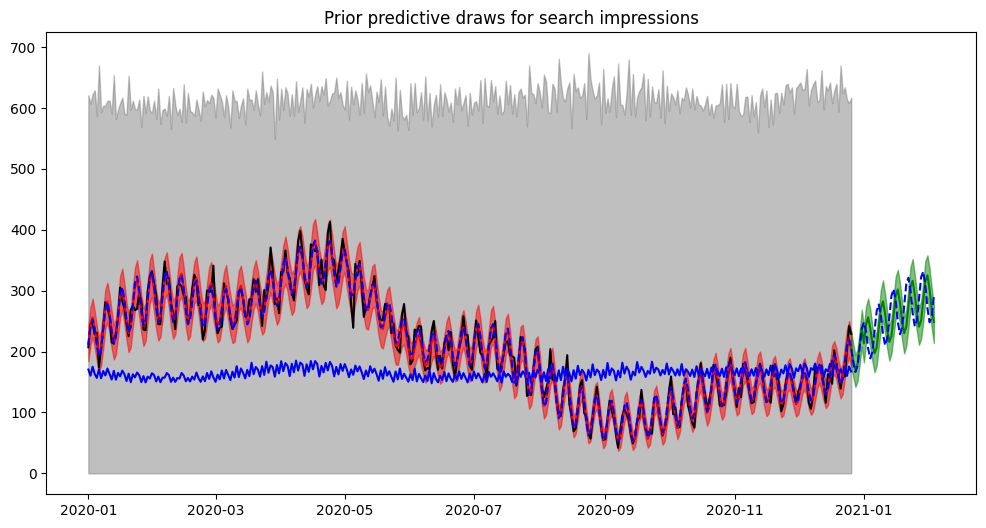

In [ ]:
plt.figure(figsize=(12, 6))
hdi_prior = pm.hdi(prior.prior["impressions"], hdi_prob=0.95)
plt.fill_between(
    date,
    hdi_prior["impressions"].sel(hdi="lower"),
    hdi_prior["impressions"].sel(hdi="higher").values,
    color="gray",
    alpha=0.5,
)
plt.plot(date, train_data["impressions"], color="black")
plt.plot(date, prior.prior["impressions"].mean(dim=("chain", "draw")), color="blue")
plt.plot(
    date,
    trace.posterior_predictive["impressions"].mean(dim=("chain", "draw")),
    color="red",
)
hdi_posterior = pm.hdi(trace.posterior_predictive["impressions"], hdi_prob=0.95)
plt.fill_between(
    date,
    hdi_posterior["impressions"].sel(hdi="lower"),
    hdi_posterior["impressions"].sel(hdi="higher"),
    color="red",
    alpha=0.5,
)
hdi_posterior_new = pm.hdi(
    posterior_test.posterior_predictive["impressions"], hdi_prob=0.95
)
plt.plot(
    hdi_posterior_new["date"],
    posterior_test.posterior_predictive["impressions"].mean(dim=("draw", "chain")),
    color="green",
)
plt.fill_between(
    hdi_posterior_new["date"],
    hdi_posterior_new["impressions"].sel(hdi="lower"),
    hdi_posterior_new["impressions"].sel(hdi="higher"),
    color="green",
    alpha=0.5,
)
plt.plot(data["date"], impression_rate * lam, color="blue", linestyle="--")
plt.title("Prior Vs Posterior Predictive draws for search impressions")

Text(0.5, 1.0, 'Prior predictive draws for search clicks')

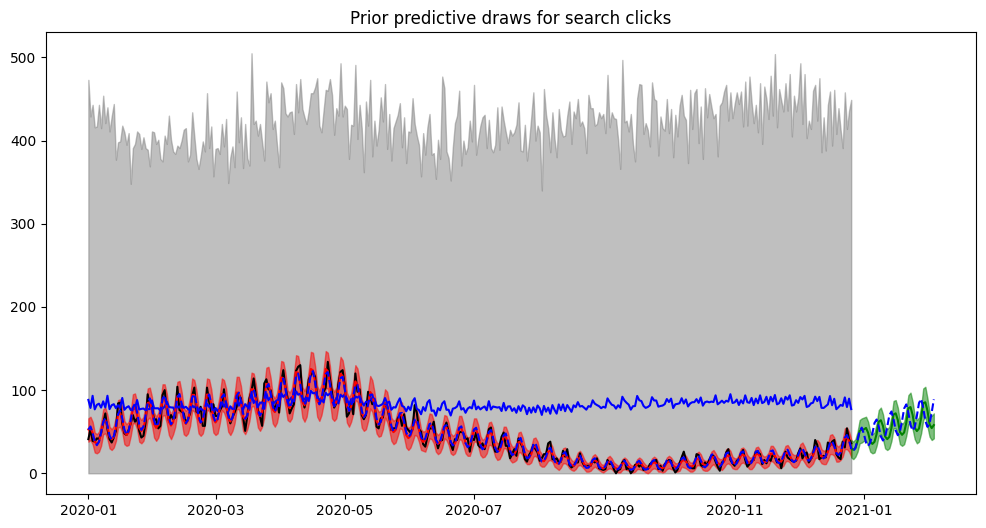

In [254]:
plt.figure(figsize=(12, 6))
hdi_prior = pm.hdi(prior.prior["clicks"], hdi_prob=0.95)
plt.fill_between(
    date,
    hdi_prior["clicks"].sel(hdi="lower"),
    hdi_prior["clicks"].sel(hdi="higher").values,
    color="gray",
    alpha=0.5,
)
plt.plot(date, train_data["observed_clicks"], color="black")
plt.plot(date, prior.prior["clicks"].mean(dim=("chain", "draw")), color="blue")
plt.plot(
    date, trace.posterior_predictive["clicks"].mean(dim=("chain", "draw")), color="red"
)
hdi_posterior = pm.hdi(trace.posterior_predictive["clicks"], hdi_prob=0.95)
plt.fill_between(
    date,
    hdi_posterior["clicks"].sel(hdi="lower"),
    hdi_posterior["clicks"].sel(hdi="higher"),
    color="red",
    alpha=0.5,
)
hdi_posterior_new = pm.hdi(posterior_test.posterior_predictive["clicks"], hdi_prob=0.95)
plt.plot(
    hdi_posterior_new["date"],
    posterior_test.posterior_predictive["clicks"].mean(dim=("draw", "chain")),
    color="green",
)
plt.fill_between(
    hdi_posterior_new["date"],
    hdi_posterior_new["clicks"].sel(hdi="lower"),
    hdi_posterior_new["clicks"].sel(hdi="higher"),
    color="green",
    alpha=0.5,
)
plt.plot(data["date"], impression_rate * lam * click_rate, color="blue", linestyle="--")
plt.title("Prior predictive draws for search clicks")